https://arxiv.org/pdf/2501.15564

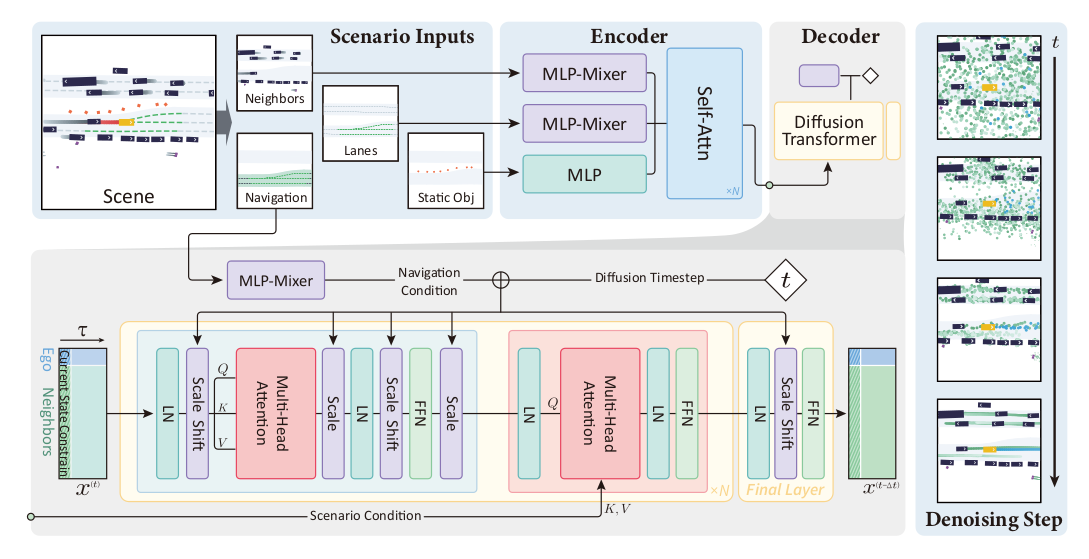

# Diffusion Planner 论文详解

## 一、论文概况与核心思想

这篇题为 **《Diffusion Planner: 利用扩散模型实现高质量自动驾驶闭环规划》** 的论文发表于 ICLR 2025。其核心思想是：

- 将自动驾驶中的**规划任务**与**周围车辆运动预测任务**统一为一个**未来轨迹生成任务**；
- 使用**扩散模型（Diffusion Model）** 强大的分布拟合能力，联合建模自车（ego vehicle）与邻近车辆的未来轨迹；
- 利用扩散模型的**引导机制（guidance）**，在推理阶段灵活调整驾驶行为（如速度、舒适性、碰撞避免），**无需重新训练**；
- 在 nuPlan 基准和自采的配送车数据集上，实现了**不依赖规则后处理**的 SOTA 闭环规划性能。

---

## 二、背景与动机

### 2.1 现有自动驾驶规划方法的不足

1. **行为克隆（Behavior Cloning）的局限**  
   早期使用 CNN、RNN，后来扩展到 Transformer。但这类方法缺乏对**多模态驾驶行为**的理论建模能力，容易在闭环规划中产生**误差累积**，导致严重的安全问题。

2. **对规则后处理的依赖**  
   为了弥补学习模型的不足，大多数方法仍然依赖规则来细化或选择生成的轨迹（如 PDM、PLUTO 等）。这在一定程度上违背了“用学习替代规则”的初衷。

3. **缺乏灵活性与可控性**  
   学习模型的输出难以根据用户需求进行调节；现有方法通过添加额外损失函数来约束行为，但难以平衡多个目标，且训练后行为调整困难。

4. **扩散模型在规划中未被充分挖掘**  
   扩散模型已在决策领域（如 Janner et al., 2022）和运动预测、交通仿真中有所应用，但针对自动驾驶**规划**的工作较少，且已有方法仅将扩散损失简单叠加到现有框架，未做针对性设计，仍依赖后处理。

---

## 三、方法论详解

### 3.1 任务重新定义：联合规划与预测

论文将规划问题重新定义为：

> 在给定条件 $ C $（当前状态、历史信息、车道、导航）下，**同时生成自车和 $ M $ 个邻近车辆未来 $ \tau $ 个时间步的轨迹**。

目标轨迹 $ x^{(0)} $ 结构如下：

$$
x^{(0)} =
\begin{bmatrix}
x^{(0)}_{\text{ego}} \\
x^{(0)}_{\text{neighbor}_1} \\
\vdots \\
x^{(0)}_{\text{neighbor}_M}
\end{bmatrix}
$$

每个车辆的状态包含：**坐标（x, y）** 和 **航向角的正弦/余弦值**（$\sin\theta, \cos\theta$）。这些信息足够下游 LQR 控制器使用。

选择最近的 $ M $ 辆邻近车辆进行预测。这种联合建模的好处是能够捕捉自车与周围车辆的**交互与合作行为**。

### 3.2 Diffusion Planner 模型架构

论文采用基于 **DiT（Diffusion Transformer）** 的架构，核心在于如何将噪声化的未来轨迹 $ x^{(t)} $ 与条件信息 $ C $ 融合。模型结构如图 1 所示，包含以下模块：

#### 3.2.1 车辆信息集成

- 将噪声轨迹 $ x^{(t)} $ 与每辆车的**当前状态**拼接：$ x_0 = [x^0_{\text{ego}}, x^0_{\text{neighbor}_1}, \ldots ]^T $。
- 该拼接作为约束，为去噪过程提供明确的起点。
- **关键设计**：自车的速度、加速度等动态信息被**排除**，只使用位置和航向。这是为了迫使模型不依赖短期动态捷径，提升闭环鲁棒性。
- 通过多头自注意力机制实现不同车辆之间的信息交互。

#### 3.2.2 历史状态与车道信息融合

- 历史状态 $ S_{\text{neighbor}} \in \mathbb{R}^{L \times D_{\text{neighbor}}} $（L 个历史时间步，每个包含坐标、航向、速度、尺寸、类别等）。
- 车道信息 $ S_{\text{lane}} \in \mathbb{R}^{P \times D_{\text{lane}}} $（P 个折线点，包含坐标、红绿灯、限速等）。
- **使用 MLP-Mixer** 网络（而非复杂的编码器）提取信息密集的表示。MLP-Mixer 通过交替在向量维度和特征维度上应用 MLP 混合：
  $$
  S = S + \text{MLP}(S^T)^T,\quad S = S + \text{MLP}(S)
  $$
- 对 MLP-Mixer 输出进行池化，再与静态物体信息（通过 MLP 提取）拼接，送入一个普通的 Transformer 编码器，得到编码特征 $ Q_f $。
- 融合方式：$ x = x + \text{MHCA}(x, Q_f) $，随后接 FFN。

#### 3.2.3 导航信息融合

- 导航信息 $ S_{\text{route}} \in \mathbb{R}^{(K \times P) \times D_{\text{route}}} $（K 条路径车道，坐标信息）。
- 同样用 MLP-Mixer 提取导航表示 $ Q_n $。
- 将 $ Q_n $ 与扩散时间步条件 $ Q_t $ 相加，通过 **adaptive LayerNorm** 块应用到所有 token，引导轨迹生成。

### 3.3 训练目标

模型参数化为 $ \mu_\theta(x^{(t)}, t, C) $，目标是预测原始干净轨迹 $ x^{(0)} $。训练损失为：

$$
\mathcal{L}_\theta = \mathbb{E}_{x^{(0)}, t \sim U(0,1), x^{(t)} \sim q_{t0}(x^{(t)}|x^{(0)})} \left[ \|\mu_\theta(x^{(t)}, t, C) - x^{(0)}\|^2 \right]
$$

得到分数函数：
$$
s_\theta = \frac{\alpha_t \mu_\theta - x^{(t)}}{\sigma_t^2}
$$

该分数用于去噪过程。

### 3.4 规划行为对齐：无需训练的引导机制

扩散模型与能量模型（EBM）的紧密联系允许通过**分类器引导**在推理时调整行为。论文采用**扩散后验采样（Diffusion Posterior Sampling）** 实现训练免引导：

$$
\nabla_{x^{(t)}} \log p_t(x^{(t)}) \approx \nabla_{x^{(t)}} \log q_t(x^{(t)}) - \nabla_{x^{(t)}} \mathcal{E}\left( \mu_\theta(x^{(t)}, t, C) \right)
$$

其中 $\mathcal{E}(\cdot)$ 是可微的能量函数，用于编码期望行为。论文列举了四种能量函数：

1. **目标速度保持**：比较规划平均速度与目标速度的差异。
2. **舒适性**：测量状态超过预定义限制（如加速度、加加速度）的量。
3. **碰撞避免**：基于符号距离计算碰撞风险。
4. **可行驶区域保持**：计算车辆偏离车道的距离。

这些能量函数可以**灵活组合**，例如图 2 所示：仅用碰撞引导时车辆可能为了躲避后车而驶离道路；加入可行驶区域引导后，车辆在保持安全的同时留在道路上。

### 3.5 实际实现细节

- **数据增强**：对当前状态添加随机扰动，然后进行插值以创建物理可行的过渡，使模型能抵抗扰动并回归真实轨迹。
- **坐标变换**：将数据从全局坐标系转换到**自车中心坐标系**。
- **归一化**：使用 z-score 归一化，使数据分布均值接近 0，稳定训练。
- **推理加速**：使用 DPM-Solver 快速采样，低温度采样增强确定性。
- **性能**：可完成 8 秒规划（10 Hz），包含邻近车辆预测，推理频率约 20 Hz。

---

## 四、实验与结果

### 4.1 数据集与评估设置

- **nuPlan**：大规模真实世界自动驾驶规划基准。使用 Val14、Test14、Test14-hard 三个子集。
- **评估模式**：闭环**非反应式（non-reactive）** 和**反应式（reactive）** 两种。
- **评分**：0-100，综合多个指标（碰撞、可行驶区域、进度、舒适性等）。
- **自采数据集**：使用 Haomo.AI 配送车采集 200 小时真实数据，集成到 nuPlan 框架，验证跨驾驶风格迁移性。

### 4.2 对比基线

- **规则/混合**：IDM、PDM-Closed、PDM-Hybrid、PLUTO（混合）。
- **学习型**：PDM-Open（*表示使用预搜索参考线）、UrbanDriver、GameFormer w/o refine、PlanTF、PLUTO w/o refine。
- **本文方法**：Diffusion Planner（纯学习）、Diffusion Planner w/ refine（加后处理）。

### 4.3 主要结果

#### nuPlan 基准（表 1）

- **Diffusion Planner（无后处理）** 在学习型方法中取得 SOTA：Test14-hard 上 75.99/69.22（NR/R），显著超过 PlanTF（69.70/61.61）和 PLUTO w/o refine（70.03/59.74）。
- **Diffusion Planner w/ refine** 在多个基准上**超过人类水平**，例如 Test14 上 94.80/91.75，超过 PDM-Hybrid 和 PLUTO。
- 这验证了扩散模型生成高质量轨迹的能力，后处理仅需轻微调整即可达到最佳。

#### 配送车数据集（表 2）

- 很多为 nuPlan 定制的基线（PDM、GameFormer、PLUTO）性能下降，而 **Diffusion Planner 保持高分**（92.08），展示强迁移性。
- 说明本文方法不依赖特定场景假设，可适应不同驾驶行为（如保守、自行车道交互）。

### 4.4 定性结果

图 3 展示狭窄道路转弯场景：

- **Diffusion Planner** 生成平滑轨迹，准确预测前车速度，体现联合建模优势。
- GameFormer 无细化轨迹不平滑，预测不准。
- PlanTF 和 PLUTO 虽然采样多条轨迹，但多数质量低。

### 4.5 多模态与引导能力

- **多模态规划**：在无导航信息时，同一初始位置可生成左转、右转、直行三种行为；提供导航后准确跟随。
- **目标速度引导**：屏蔽所有限速信息后，通过引导可使速度调整到 10-14 m/s 区间，且速度变化平滑。
- **舒适性引导**：在碰撞引导基础上叠加舒适性引导，有效降低纵向 jerk。
- 这些结果表明扩散模型天然支持多模态行为，且引导机制可灵活注入偏好。

### 4.6 消融实验

- **数据处理**：
  - 去掉 z-score 归一化：分数从 89.19 降至 85.02。
  - 去掉插值：83.78。
  - 去掉数据增强：76.53，说明增强对闭环鲁棒性至关重要。
- **自车当前状态处理**：
  - 保留速度/加速度/横摆角速度（w/ ego state）：78.65，模型学到捷径。
  - 使用状态丢弃编码器（w/ SDE）：82.90，有缓解但仍不如直接丢弃。
  - 完全不使用当前状态：81.11，说明当前状态约束有用，但应仅提供位置航向。
- **预测车辆数量 M**：过多邻近车辆会引入噪声，降低性能，但大多数 M 选择仍优于 PlanTF（图 6）。
- **推理超参数**：低温度采样提高稳定性；DPM-Solver 使模型对去噪步数鲁棒（图 7）。

---

## 五、核心贡献总结

1. **首个将扩散模型充分适配自动驾驶闭环规划的框架**，通过联合生成自车与邻近车辆轨迹，实现预测与规划的统一。
2. **架构创新**：利用 MLP-Mixer 高效融合历史、车道、导航信息；设计自车当前状态约束方式，避免学习捷径。
3. **训练免引导机制**：基于扩散后验采样，在推理阶段灵活组合多种可微能量函数，实现安全与个性化驾驶行为对齐，无需额外训练或分类器。
4. **SOTA 性能**：在 nuPlan 和自采配送车数据集上，纯学习模型取得最佳成绩；加后处理后超越人类水平。
5. **强迁移性**：不依赖 nuPlan 特定规则，可适应不同驾驶风格和场景。

---

## 六、局限性与未来方向

论文在附录 E 中讨论了局限性和未来工作，根据正文可推测潜在问题：

- 扩散模型推理计算成本相对较高（虽然已用 DPM-Solver 优化到 20 Hz，但与规则方法仍有差距）。
- 引导能量函数需要针对具体任务手动设计，其可微性可能限制了某些复杂约束的表示。
- 当前联合建模仅包含最近的 M 辆车，复杂场景下可能需要动态选择交互对象。
- 实验主要基于仿真基准，真实道路部署仍需进一步验证。

---

## 七、总结

《Diffusion Planner》通过将自动驾驶规划重构为联合轨迹生成任务，并结合扩散模型的强大表达力与灵活引导能力，解决了现有学习型规划器依赖规则后处理、缺乏可控性和迁移性差的问题。其架构设计、训练策略和推理引导机制为自动驾驶领域提供了新的范式，并在多个基准上取得了领先效果，具有重要的理论和实践价值。